# Thesis Plots Generation
This notebook contains the complete pipeline for loading radargrams and generating various plots for the thesis (e.g., patching, rangelines, comparisons).

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pdr
import logging

# Add src directory to path to import codebase modules
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

In [2]:
from dataset.processing import handle_irregular_data, to_decibels

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('thesis_plots')

In [3]:
# Example file ID to load. Just specify the number, e.g., '02685401'
file_id = '01970402' #07422501

# Determine the paths based on ID
if file_id:
    possible_real_paths = [
        f's_{file_id}_rgram.xml',
        os.path.join('..', 'data', 'train', 'real', f's_{file_id}_rgram.xml'),
        os.path.join('..', 'data', 'val', 'real', f's_{file_id}_rgram.xml')
    ]
    possible_sim_paths = [
        f's_{file_id}_sim.xml',
        os.path.join('..', 'data', 'train', 'sim', f's_{file_id}_sim.xml'),
        os.path.join('..', 'data', 'val', 'sim', f's_{file_id}_sim.xml')
    ]
    
    real_file_path = next((p for p in possible_real_paths if os.path.exists(p)), f's_{file_id}_rgram.xml')
    sim_file_path = next((p for p in possible_sim_paths if os.path.exists(p)), f's_{file_id}_sim.xml')
else:
    real_file_path = 's_02685401_rgram.xml'
    sim_file_path = 's_02685401_sim.xml'

def load_radargram(file_path):
    data = pdr.read(file_path)
    if 'MRO_SHARAD_US_Radargram' in data.keys():
        R = data['MRO_SHARAD_US_Radargram']
    else:
        R = data['Combined_Clutter_Simulation']
    R = handle_irregular_data(R, file_path, logger)
    return R

print(f"Loading Real: {real_file_path}")
R_real = load_radargram(real_file_path)
print(f"Loading Sim: {sim_file_path}")
R_sim = load_radargram(sim_file_path)

print(f"Real shape: {R_real.shape}")
print(f"Sim shape: {R_sim.shape}")


Loading Real: s_01970402_rgram.xml
Loading Sim: s_01970402_sim.xml
Real shape: (3600, 3727)
Sim shape: (3600, 3727)


In [4]:
# Conversion to decibels for visualization
R_real_db = to_decibels(R_real)
R_sim_db = to_decibels(R_sim)

print(f"Real Radargram (dB) - Min: {R_real_db.min():.2f}, Max: {R_real_db.max():.2f}, Median: {np.median(R_real_db):.2f}")
print(f"Sim Radargram (dB) - Min: {R_sim_db.min():.2f}, Max: {R_sim_db.max():.2f}, Median: {np.median(R_sim_db):.2f}")


Real Radargram (dB) - Min: -114.04, Max: -2.54, Median: -86.26
Sim Radargram (dB) - Min: -260.00, Max: -232.88, Median: -260.00


## Visualizing Radargrams (Comparison)

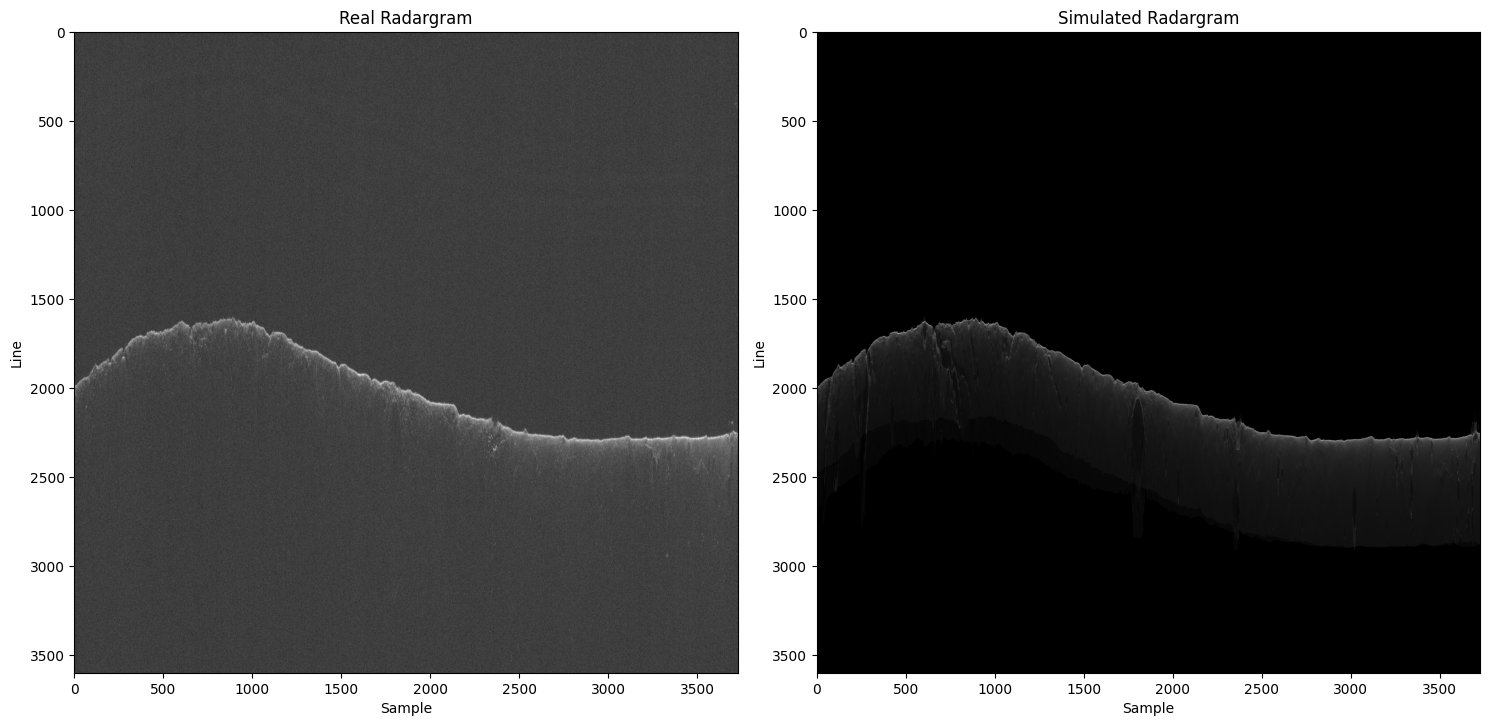

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].imshow(R_real_db, cmap='gray', aspect='equal')
axes[0].set_title('Real Radargram')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Line')

axes[1].imshow(R_sim_db, cmap='gray', aspect='equal')
axes[1].set_title('Simulated Radargram')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Line')

plt.tight_layout()
plt.show()

## Linear vs Decibel (dB) Scale Comparison
Visualizing the difference between raw linear returns and logarithmic (dB) mapping for both Real and Simulated radargrams.

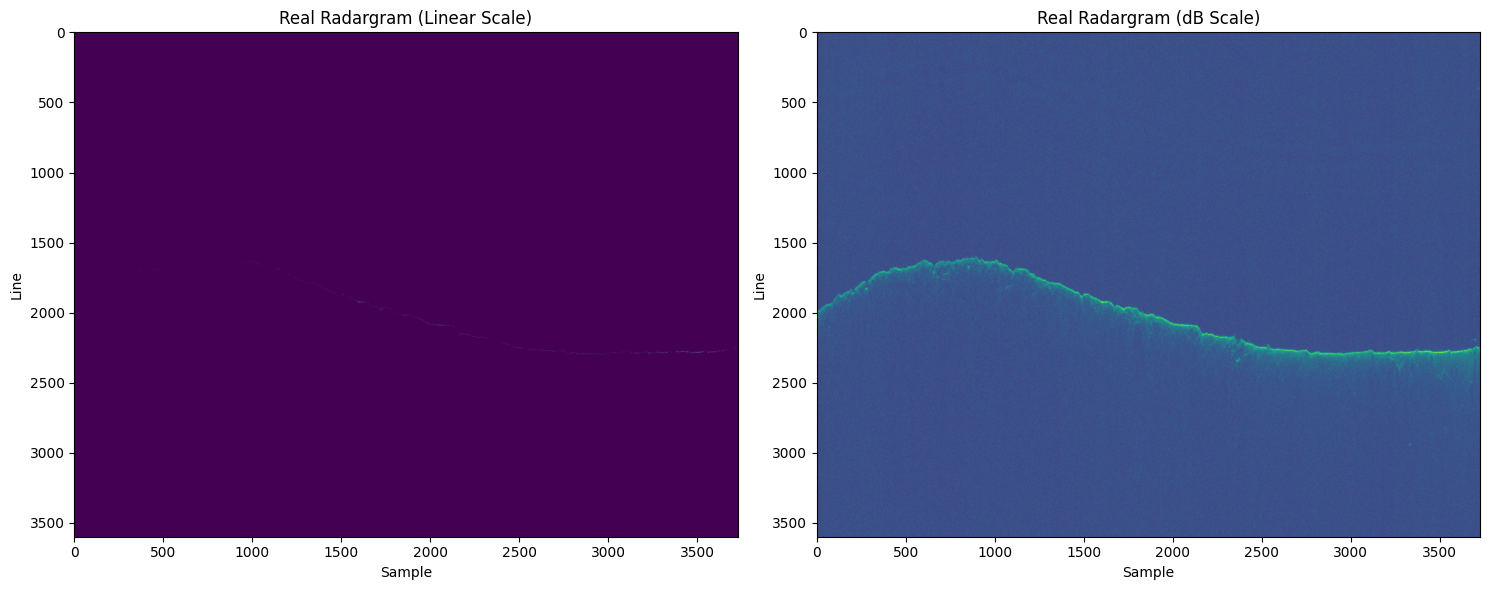

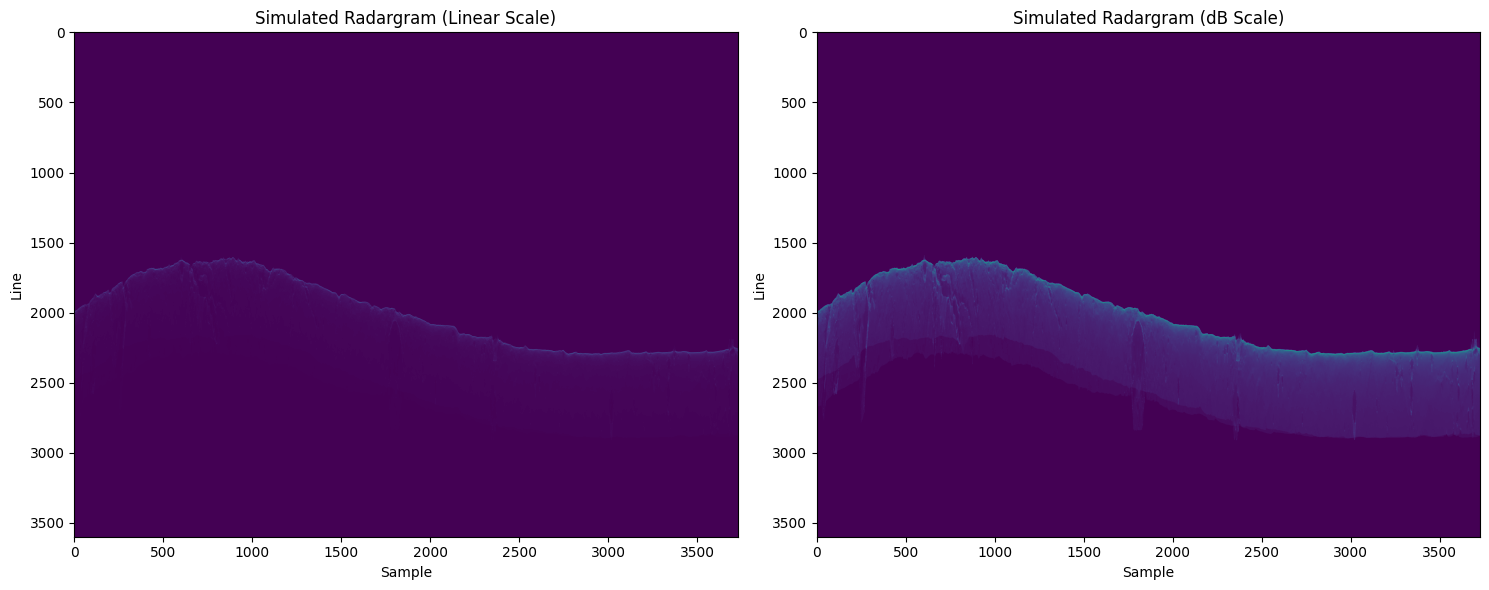

In [6]:
# Comparison for Real Radargram
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(R_real, cmap='viridis', aspect='auto')
axes[0].set_title('Real Radargram (Linear Scale)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Line')

axes[1].imshow(R_real_db, cmap='viridis', aspect='auto')
axes[1].set_title('Real Radargram (dB Scale)')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Line')

plt.tight_layout()
plt.show()

# Comparison for Simulated Radargram
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(R_sim, cmap='viridis', aspect='auto')
axes[0].set_title('Simulated Radargram (Linear Scale)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Line')

axes[1].imshow(R_sim_db, cmap='viridis', aspect='auto')
axes[1].set_title('Simulated Radargram (dB Scale)')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Line')

plt.tight_layout()
plt.show()

## Single Patch Schematic Explanation
A zoomed-in look at a single extracted patch to illustrate the geometry constraints: Width (W), Height (H), Overlap (O) and spatial calculation points (Surface Y, Center Y).

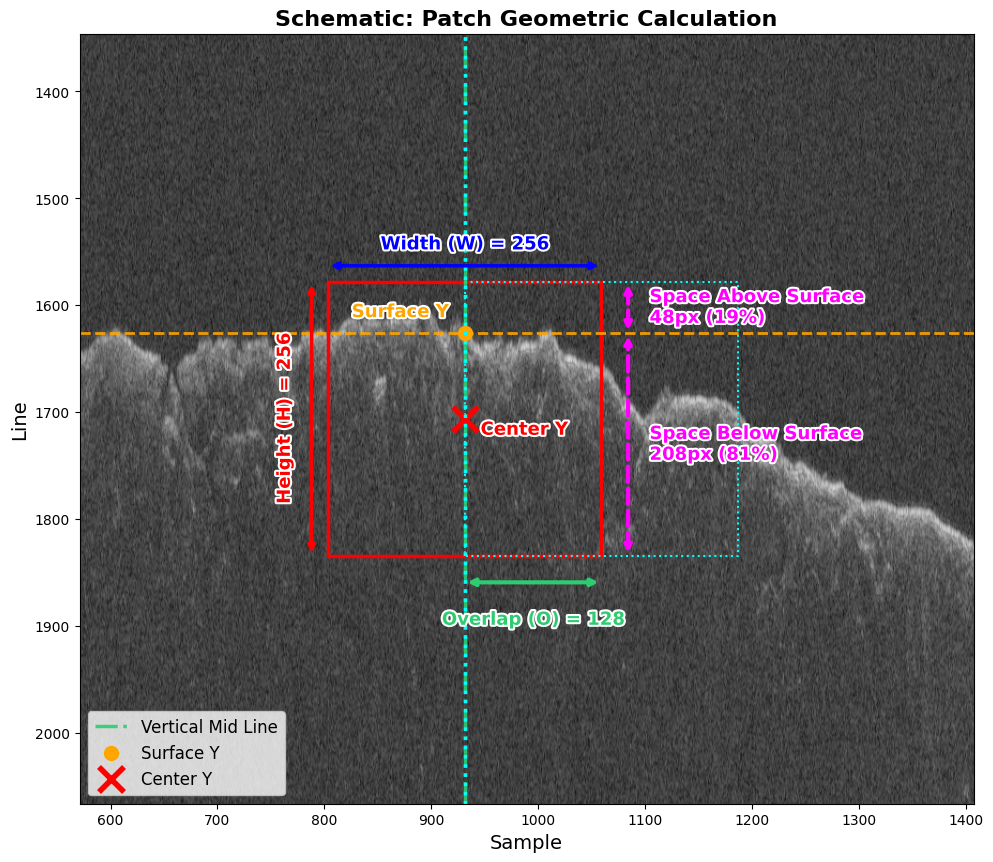

In [7]:
import matplotlib.patches as patches
import matplotlib.patheffects as patheffects
from dataset.processing import calculate_box

patch_size = 256
overlap = 128
M = R_real_db.shape[1]
h_step = patch_size - overlap

# Choose a point at 1/4th of the width as an example center
x_center = M // 4

box, y_current, y_max, y_min = calculate_box(x_center, width=patch_size, height=patch_size, R=R_real_db)

if box is not None:
    left_edge, right_edge, top_edge, bottom_edge = box
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    zoom_margin = int(patch_size / 1.1)  # slightly bigger zoom to fit the labels
    # Configure Y-axis inverted style (common for images where line 0 is top)
    ax.set_ylim(bottom_edge + zoom_margin, top_edge - zoom_margin)
    ax.set_xlim(left_edge - zoom_margin, right_edge + int(zoom_margin * 1.5)) # extra space on right for text
    
    # Draw the radargram zoomed
    ax.imshow(R_real_db, cmap='gray', aspect='equal')
    
    # 1. Main Patch Rectangle
    rect = patches.Rectangle((left_edge, top_edge), patch_size, patch_size, linewidth=2.5, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Vertical mid line (as defined by user)
    ax.axvline(x_center, color='#2ECC71', linestyle='-.', linewidth=2.5, alpha=0.9, label='Vertical Mid Line')
    
    label_fontsize = 13
    text_effects = [patheffects.withStroke(linewidth=3, foreground='white')]
    
    # 2. Key Coordinates
    ax.plot(x_center, y_current, 'o', color='orange', markersize=10, label='Surface Y')
    ax.plot(x_center, top_edge + patch_size//2, 'x', color='red', markersize=18, markeredgewidth=4, label='Center Y')
    ax.axhline(y_current, color='orange', linestyle='--', linewidth=2, alpha=0.9)
    
    # Label surface Y & Center Y
    ax.text(x_center - 15, y_current - 15, 'Surface Y', color='orange', fontsize=label_fontsize, fontweight='bold', path_effects=text_effects, ha='right')
    ax.text(x_center + 15, (top_edge + patch_size//2) + 15, 'Center Y', color='red', fontsize=label_fontsize, fontweight='bold', path_effects=text_effects, ha='left')
    
    # 3. Label Width
    ax.annotate('', xy=(right_edge, top_edge - 15), xytext=(left_edge, top_edge - 15),
                arrowprops=dict(arrowstyle='<|-|>', color='blue', lw=2.5))
    ax.text(x_center, top_edge - 35, f'Width (W) = {patch_size}', color='blue', fontsize=label_fontsize, ha='center', va='center', fontweight='bold', path_effects=text_effects)
    
    # 4. Label Height
    ax.annotate('', xy=(left_edge - 15, bottom_edge), xytext=(left_edge - 15, top_edge),
                arrowprops=dict(arrowstyle='<|-|>', color='red', lw=2.5))
    ax.text(left_edge - 40, top_edge + patch_size//2, f'Height (H) = {patch_size}', color='red', fontsize=label_fontsize, ha='center', va='center', rotation='vertical', fontweight='bold', path_effects=text_effects)
    
    # 5. Label Overlap
    # The overlap region spans from the start of the next patch frame to the end of the current frame
    next_left_edge = (x_center + h_step) - patch_size//2
    
    # Draw theoretical next patch left border (changed to bright cyan to avoid dark green clash)
    ax.axvline(next_left_edge, color='cyan', linestyle=':', lw=2.5)
    rect_next = patches.Rectangle((next_left_edge, top_edge), patch_size, patch_size, linewidth=1.5, edgecolor='cyan', facecolor='none', linestyle=':')
    ax.add_patch(rect_next)
    
    ax.annotate('', xy=(right_edge, bottom_edge + 25), xytext=(next_left_edge, bottom_edge + 25),
                arrowprops=dict(arrowstyle='<|-|>', color='#2ECC71', lw=3))
    ax.text(next_left_edge + overlap//2, bottom_edge + 60, f'Overlap (O) = {overlap}', color='#2ECC71', fontsize=label_fontsize, ha='center', va='center', fontweight='bold', path_effects=text_effects)
    
    # 6. Info about Space Above and Below Surface
    # Space above the surface Y
    space_above = y_current - top_edge
    space_below = bottom_edge - y_current
    pct_above = int(round((space_above / patch_size) * 100))
    pct_below = int(round((space_below / patch_size) * 100))
    
    bright_purple = '#FF00FF' # Much brighter magenta/purple so it pops
    
    ax.annotate('', xy=(right_edge + 25, top_edge), xytext=(right_edge + 25, y_current),
                arrowprops=dict(arrowstyle='<|-|>', color=bright_purple, lw=3, ls='--'))
    ax.text(right_edge + 45, top_edge + space_above//2, f'Space Above Surface\n{space_above}px ({pct_above}%)', color=bright_purple, fontsize=label_fontsize, va='center', fontweight='bold', path_effects=text_effects)
    
    # Space below the surface Y
    ax.annotate('', xy=(right_edge + 25, y_current), xytext=(right_edge + 25, bottom_edge),
                arrowprops=dict(arrowstyle='<|-|>', color=bright_purple, lw=3, ls='--'))
    ax.text(right_edge + 45, y_current + space_below//2, f'Space Below Surface\n{space_below}px ({pct_below}%)', color=bright_purple, fontsize=label_fontsize, va='center', fontweight='bold', path_effects=text_effects)
    
    plt.title("Schematic: Patch Geometric Calculation", fontsize=16, fontweight='bold')
    plt.xlabel("Sample", fontsize=14)
    plt.ylabel("Line", fontsize=14)
    
    # Move legend to not obscure labels
    plt.legend(loc='lower left', fontsize=12)
    plt.show()
else:
    print("Could not calculate bounding box for this coordinate.")


## Extracting Patches Layout (Example)

--- Patching Stats ---
Number of patches across horizon: 28
Patch dimensions: 256x256 with 128 overlap


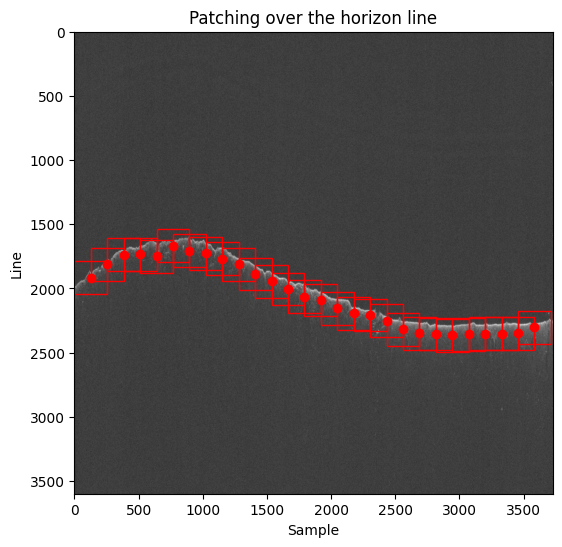

In [8]:
import matplotlib.patches as patches
from dataset.processing import calculate_box

patch_size = 256
overlap = 128
M = R_real_db.shape[1]
h_step = patch_size - overlap

centers = np.arange(patch_size//2, M-1-patch_size//2, step=h_step)

print(f"--- Patching Stats ---")
print(f"Number of patches across horizon: {len(centers)}")
print(f"Patch dimensions: {patch_size}x{patch_size} with {overlap} overlap")

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(R_real_db, cmap='gray', aspect='equal')

for x in centers:
    # compute bounding box using the main codebase logic
    box, y_current, y_max, y_min = calculate_box(x, width=patch_size, height=patch_size, R=R_real_db)
    if box is None:
        continue
    left_edge, right_edge, top_edge, bottom_edge = box
    
    rect = patches.Rectangle((left_edge, top_edge), patch_size, patch_size, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.plot(x, top_edge + patch_size//2, 'o', color='red')

plt.title("Patching over the horizon line")
plt.xlabel("Sample")
plt.ylabel("Line")
plt.show()

## Rangelines Visualization
Plot rangelines of the radargram at 1/4, 1/2, and 3/4 of the sample width.

Real Radargram Rangelines | 1/4 Width - Min: -105.53 dB, Max: -40.43 dB, Peak Line: 1626
Real Radargram Rangelines | 1/2 Width - Min: -106.73 dB, Max: -30.73 dB, Peak Line: 2017
Real Radargram Rangelines | 3/4 Width - Min: -107.75 dB, Max: -28.99 dB, Peak Line: 2287


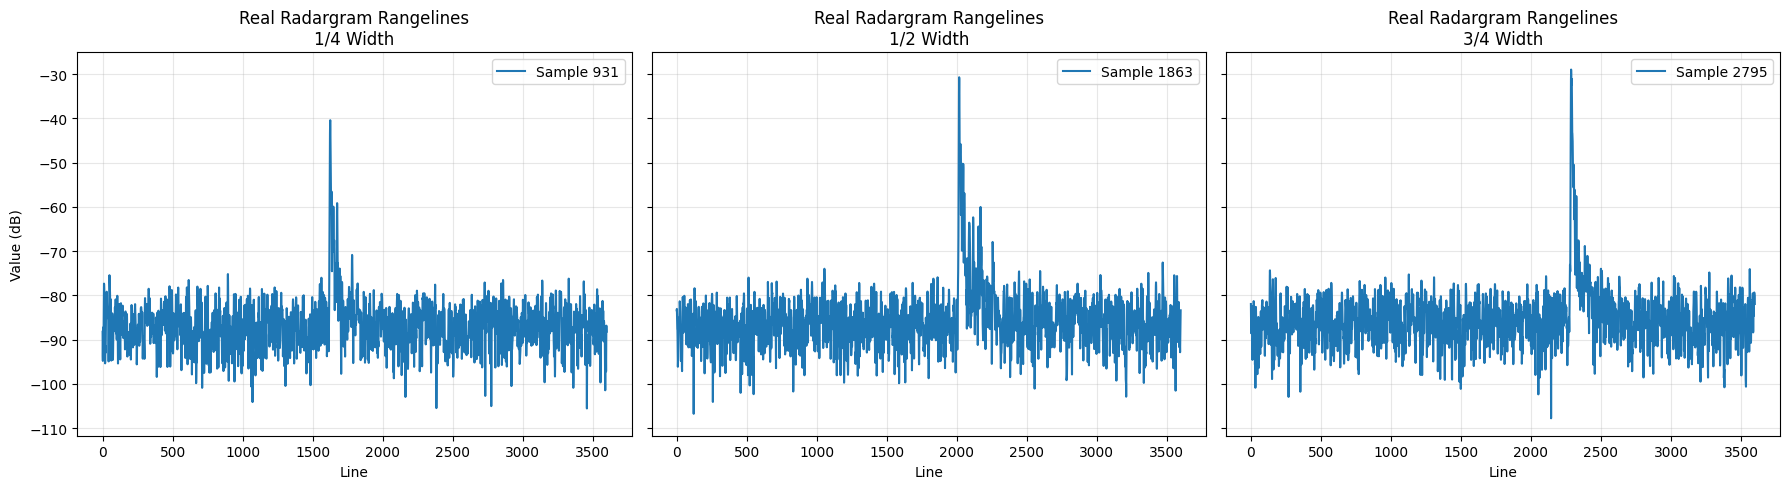

Simulated Radargram Rangelines | 1/4 Width - Min: -260.00 dB, Max: -242.83 dB, Peak Line: 1630
Simulated Radargram Rangelines | 1/2 Width - Min: -260.00 dB, Max: -243.33 dB, Peak Line: 2017
Simulated Radargram Rangelines | 3/4 Width - Min: -260.00 dB, Max: -239.07 dB, Peak Line: 2291


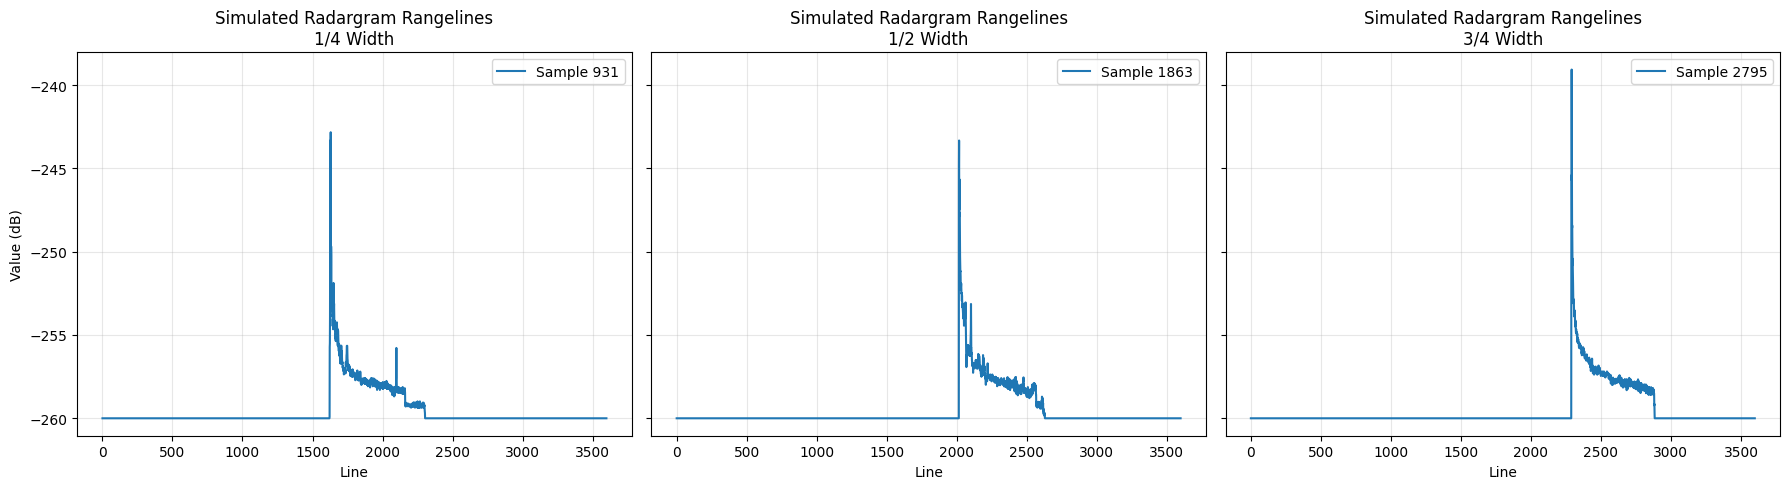

Real Radargram Rangelines (Linear Scale) | 1/4 Width - Min: 0.00 dB, Max: 0.01 dB, Peak Line: 1626
Real Radargram Rangelines (Linear Scale) | 1/2 Width - Min: 0.00 dB, Max: 0.03 dB, Peak Line: 2017
Real Radargram Rangelines (Linear Scale) | 3/4 Width - Min: 0.00 dB, Max: 0.04 dB, Peak Line: 2287


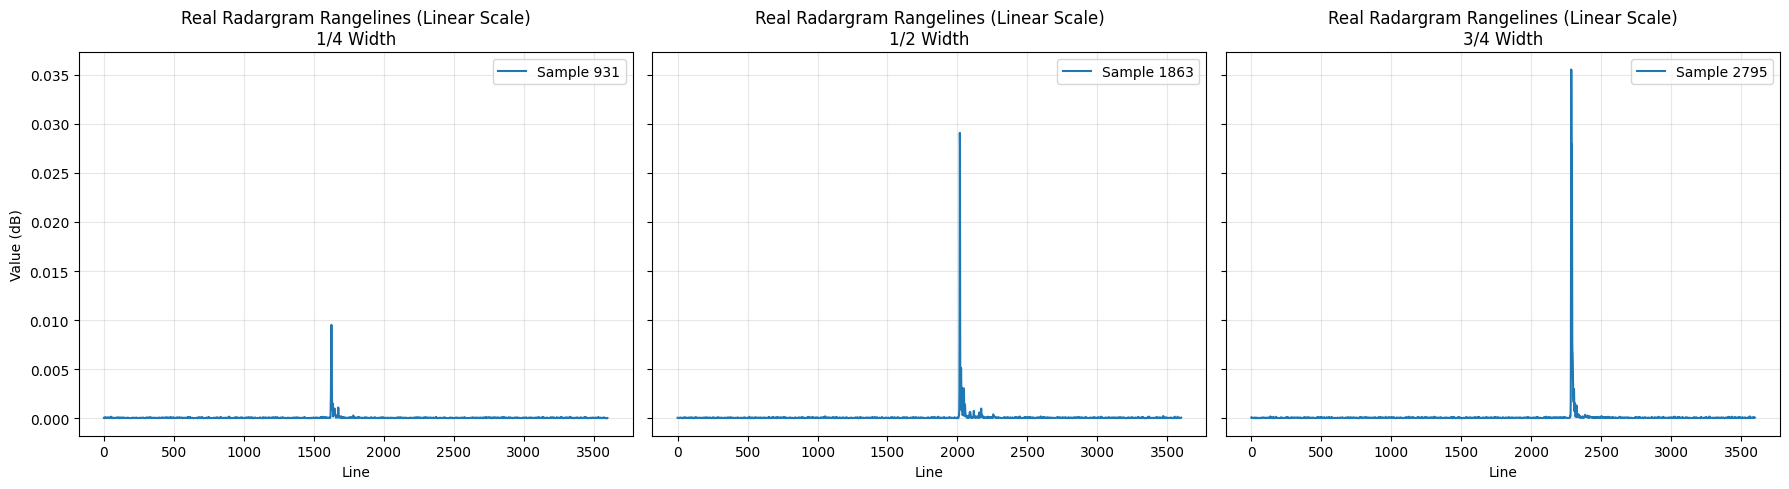

Simulated Radargram Rangelines (Linear Scale) | 1/4 Width - Min: 0.00 dB, Max: 0.00 dB, Peak Line: 1630
Simulated Radargram Rangelines (Linear Scale) | 1/2 Width - Min: 0.00 dB, Max: 0.00 dB, Peak Line: 2017
Simulated Radargram Rangelines (Linear Scale) | 3/4 Width - Min: 0.00 dB, Max: 0.00 dB, Peak Line: 2291


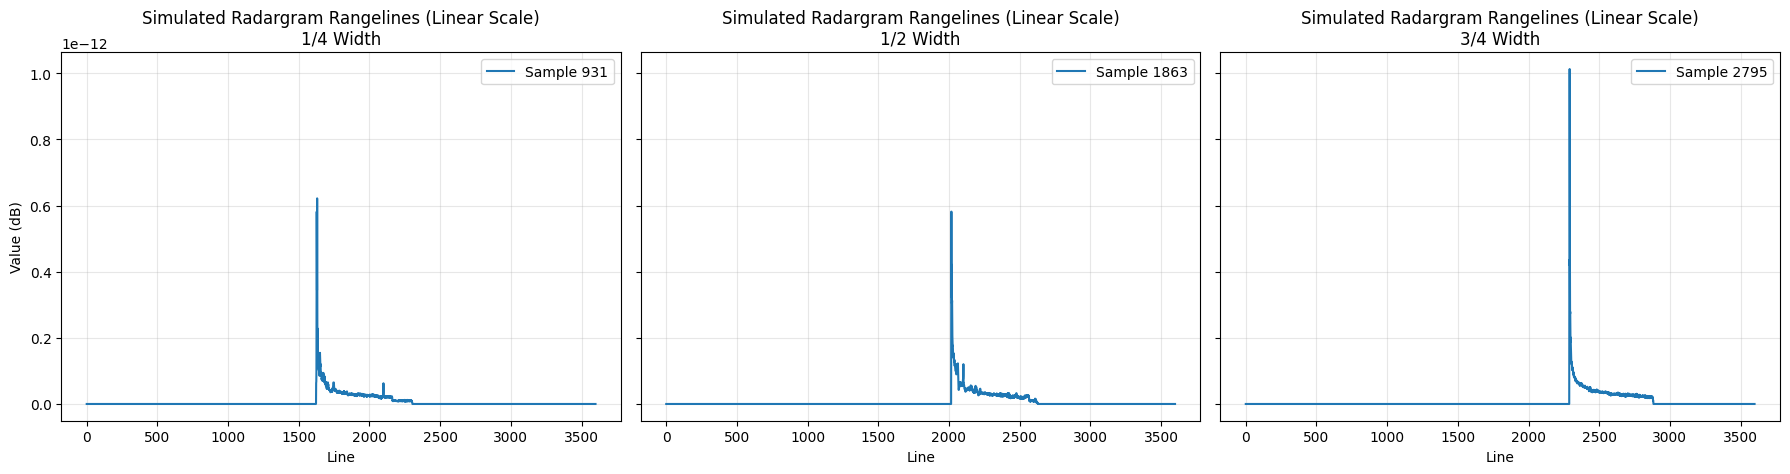

In [9]:
def plot_rangelines_separated(R_db, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    M = R_db.shape[1]
    
    lines_to_plot = [
        ("1/4 Width", M // 4),
        ("1/2 Width", M // 2),
        ("3/4 Width", 3 * M // 4)
    ]
    
    for i, (label, col_idx) in enumerate(lines_to_plot):
        axes[i].plot(R_db[:, col_idx], label=f"Sample {col_idx}")
        axes[i].set_title(f"{title}\n{label}")
        axes[i].set_xlabel("Line")
        if i == 0:
            axes[i].set_ylabel("Value (dB)")
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        r_line = R_db[:, col_idx]
        print(f"{title} | {label} - Min: {r_line.min():.2f} dB, Max: {r_line.max():.2f} dB, Peak Line: {r_line.argmax()}")
        
    plt.tight_layout()
    plt.show()

# Plot real rangelines
plot_rangelines_separated(R_real_db, "Real Radargram Rangelines")

# Plot simulated rangelines
plot_rangelines_separated(R_sim_db, "Simulated Radargram Rangelines")

# Plot real rangelines (Linear)
plot_rangelines_separated(R_real, "Real Radargram Rangelines (Linear Scale)")

# Plot simulated rangelines (Linear)
plot_rangelines_separated(R_sim, "Simulated Radargram Rangelines (Linear Scale)")


## Signal Decay with Depth
Average signal intensity across the depth (A-Scan) for both the Real and Simulated radargram to illustrate how radar returns attenuate.

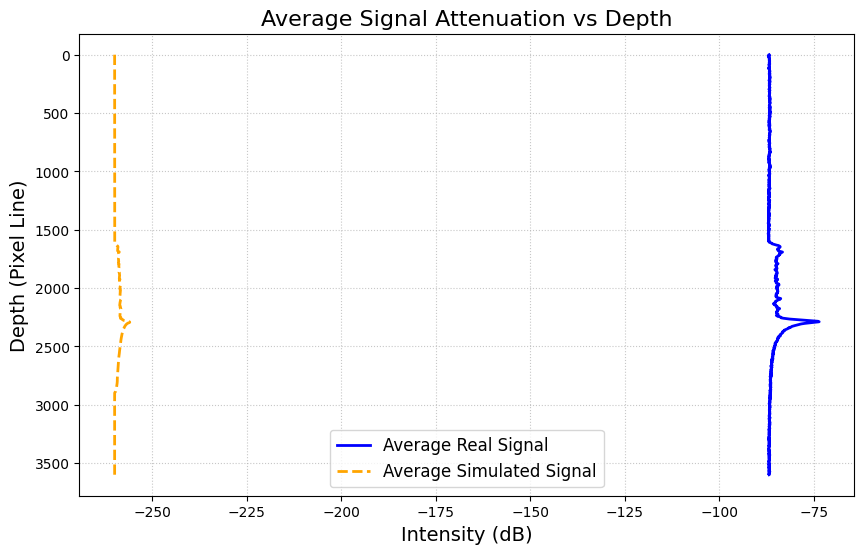

In [10]:
real_decay = np.mean(R_real_db, axis=1)
sim_decay = np.mean(R_sim_db, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
depth_pixels = np.arange(len(real_decay))

ax.plot(real_decay, depth_pixels, label='Average Real Signal', color='blue', linewidth=2)
ax.plot(sim_decay, depth_pixels, label='Average Simulated Signal', color='orange', linestyle='--', linewidth=2)

# Invert y-axis to represent depth going downwards
ax.invert_yaxis()
ax.set_title('Average Signal Attenuation vs Depth', fontsize=16)
ax.set_ylabel('Depth (Pixel Line)', fontsize=14)
ax.set_xlabel('Intensity (dB)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Effect of Varying Patch Sizes
Illustrating how the choice of patch size affects the contextual field of view for the neural network. We extract and compare patches from size `64` up to `512` anchored at the same coordinate.

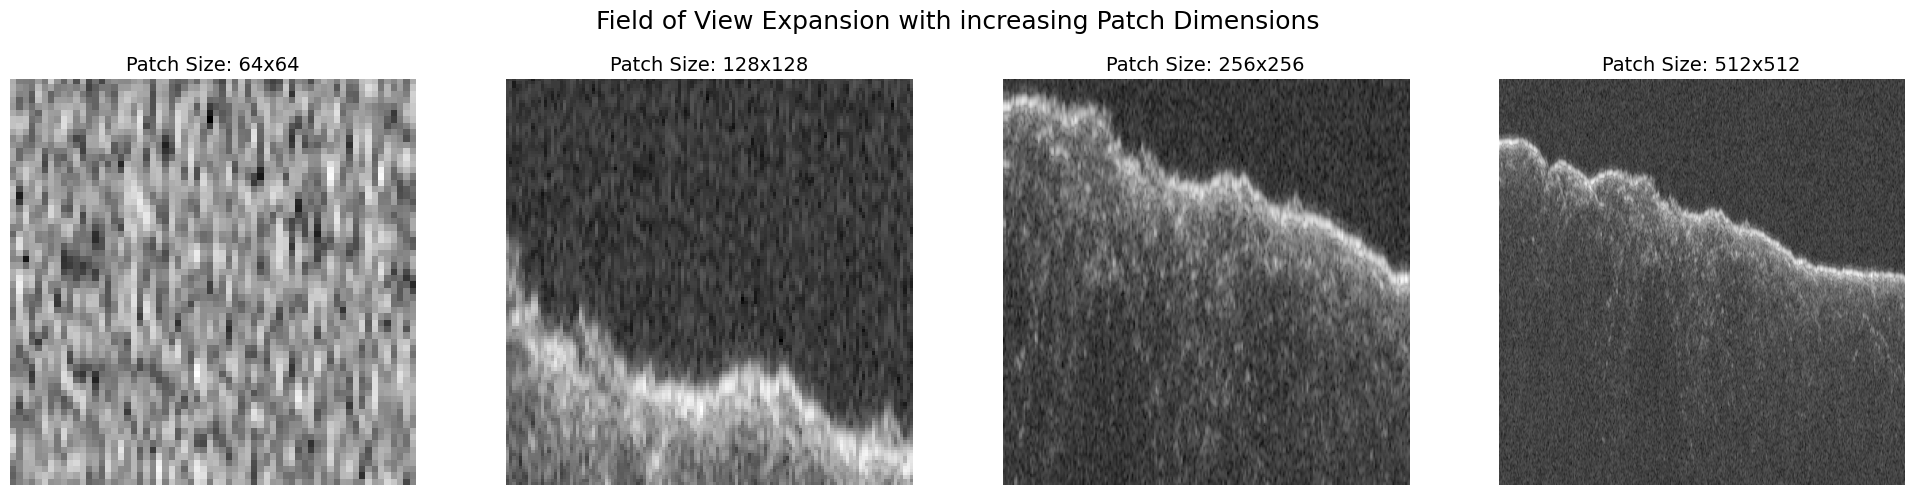

In [11]:
from dataset.processing import calculate_box

sizes_to_test = [64, 128, 256, 512]
M = R_real_db.shape[1]
x_anchor = M // 2  # Center of the radargram

fig, axs = plt.subplots(1, len(sizes_to_test), figsize=(20, 5))

for i, p_size in enumerate(sizes_to_test):
    box, y_cur, _, _ = calculate_box(x_anchor, width=p_size, height=p_size, R=R_real_db)
    if box:
        left, right, top, bottom = box
        
        # Bound checks just in case
        t, b = max(0, top), min(R_real_db.shape[0], bottom)
        l, r = max(0, left), min(R_real_db.shape[1], right)
        
        patch_data = R_real_db[t:b, l:r]
        
        axs[i].imshow(patch_data, cmap='gray', aspect='equal')
        axs[i].set_title(f'Patch Size: {p_size}x{p_size}', fontsize=14)
        axs[i].axis('off')
    else:
        axs[i].text(0.5, 0.5, 'Bounding box error', ha='center')
        axs[i].axis('off')
        
plt.suptitle('Field of View Expansion with increasing Patch Dimensions', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Advanced plots
Loading exported data from the trained model (in a compressed archive, .npz format)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CARICAMENTO DATI ---
data = np.load('thesis_data_export_2025-11-10_00-41-51_cyclegan.npz')
real_norm = data['real']
sim_norm = data['sim']
reco_norm = data['reconstructed']

# Calcolo medie (vettori di profondità)
real_decay_norm = np.mean(real_norm, axis=(0, 2))
sim_decay_norm = np.mean(sim_norm, axis=(0, 2))
reco_decay_norm = np.mean(reco_norm, axis=(0, 2))
depth_axis = np.arange(len(real_decay_norm))

# Costanti di De-normalizzazione (Fixed)
REAL_MIN, REAL_MAX = -260.0, 9.1160
SIM_MIN, SIM_MAX = -260.0, -226.1435

def denormalize(x, vmin, vmax):
    return x * (vmax - vmin) + vmin

real_db = denormalize(real_decay_norm, REAL_MIN, REAL_MAX)
reco_db = denormalize(reco_decay_norm, REAL_MIN, REAL_MAX)
sim_db = denormalize(sim_decay_norm, SIM_MIN, SIM_MAX)

# --- COSTANTI STILE ---
FIG_SIZE = (12, 8) # Formato Landscape schiacciato
COLORS = {'real': '#2E86C1', 'sim': '#E67E22', 'reco': '#27AE60'}

# ==========================================
# PLOT 1: Absolute dB
# ==========================================
plt.figure(figsize=FIG_SIZE)
plt.plot(real_db, depth_axis, label='Real (Target)', color=COLORS['real'], linewidth=2.5)
plt.plot(sim_db, depth_axis, label='Sim (Input)', color=COLORS['sim'], linestyle='--', linewidth=2)
plt.plot(reco_db, depth_axis, label='Reconstructed (GAN)', color=COLORS['reco'], linewidth=2.5)

plt.gca().invert_yaxis()
plt.title('Average Signal Attenuation Profile (Absolute dB)', fontsize=16, pad=15)
plt.xlabel('Intensity (dB)', fontsize=14)
plt.ylabel('Depth (Pixels)', fontsize=14)
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('avg_signal_attenuation_profile_db.png', dpi=300, bbox_inches='tight')
plt.close()

# ==========================================
# PLOT 2: Normalized
# ==========================================
plt.figure(figsize=FIG_SIZE)
plt.plot(real_decay_norm, depth_axis, label='Real (Target)', color=COLORS['real'], linewidth=2.5)
plt.plot(sim_decay_norm, depth_axis, label='Sim (Input)', color=COLORS['sim'], linestyle='--', linewidth=2)
plt.plot(reco_decay_norm, depth_axis, label='Reconstructed (GAN)', color=COLORS['reco'], linewidth=2.5)

plt.gca().invert_yaxis()
plt.title('Average Signal Attenuation Profile (Normalized)', fontsize=16, pad=15)
plt.xlabel('Normalized Intensity', fontsize=14)
plt.ylabel('Depth (Pixels)', fontsize=14)
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('avg_signal_attenuation_profile_normalized.png', dpi=300, bbox_inches='tight')
plt.close()